In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib.colors as mcolors
import json
import yaml
from skimage.draw import line

import geo_utils as gu

In [2]:
print(f"Bounding box in UTM: ({gu._xmin}, {gu._ymin}) to ({gu._xmax}, {gu._ymax})")
print(f"Top Left:\t({gu.LAT_MIN}, {gu.LON_MIN})\nBottom Right:\t({gu.LAT_MAX}, {gu.LON_MAX})")
print(f"Aspect Ratio (meters): {gu.HEIGHT_METERS/gu.WIDTH_METERS}, Aspect Ratio (pixels): {gu.HEIGHT_PX/gu.WIDTH_PX}")
print(f"Spray Radius: {gu.CHUNK_DIM}")

Bounding box in UTM: (489041.0228945217, 1805088.1163430738) to (489151.6696408869, 1804873.5769851631)
Top Left:	(16.326805747535087, 80.89740320760403)
Bottom Right:	(16.32486678659248, 80.89844007039832)
Aspect Ratio (meters): 1.9365858988861402, Aspect Ratio (pixels): 1.9389576734811402
Spray Radius: 3


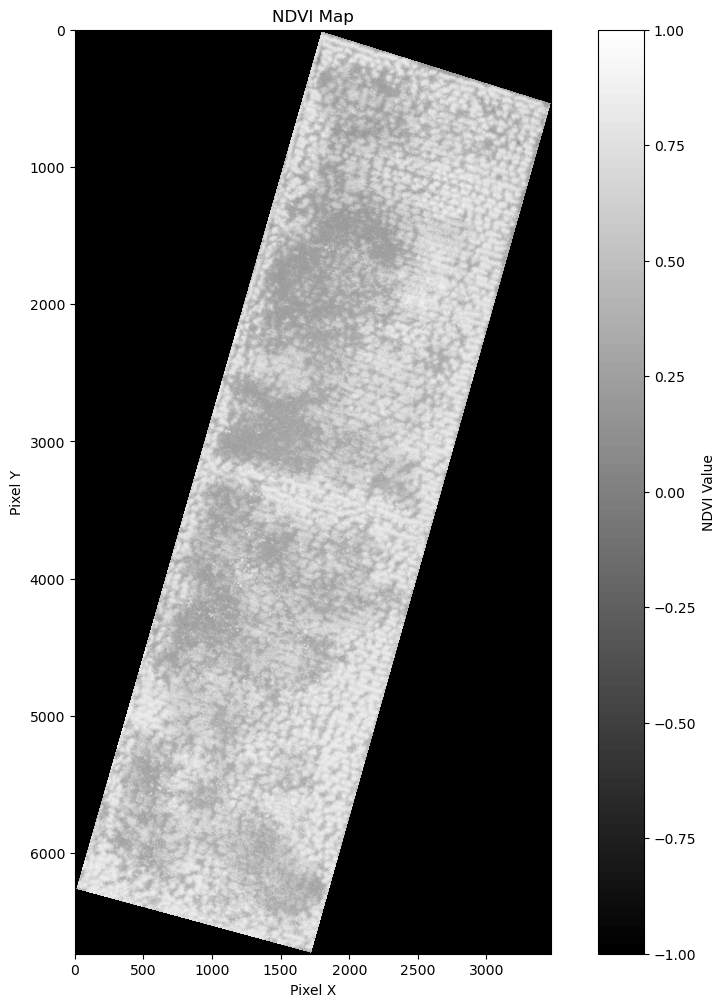

In [3]:
colors = [(0,0,0), (1,1,1)]
n_bins = 100
cmap = LinearSegmentedColormap.from_list("white_black", colors, N=n_bins)
norm = Normalize(vmin=-1, vmax=1)

plt.figure(figsize=(12, 12))
img = plt.imshow(gu.ndvi, cmap=cmap, norm=norm)
plt.colorbar(img, label='NDVI Value')

plt.title('NDVI Map')
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')

plt.imshow(np.ma.masked_less(gu.ndvi, -1), cmap=cmap, norm=norm)
plt.show()

In [4]:
infected_chunks = []

with open("config.yaml") as f:
    config = yaml.safe_load(f)
cutoffs = {
    "avg": config["infection_threshold_ndvi"],
    "mask_ratio": config["chunk_overflow_mask_ratio"]
}

def is_infected(chunk, thresholds, out_arr=infected_chunks):
    chunk_masked = np.ma.masked_equal(chunk, gu.NDVI_NAN_MASK)

    chunk_mask_ratio = np.count_nonzero(chunk_masked.mask) / chunk.size
    chunk_avg = np.mean(chunk_masked)
    
    if (chunk_mask_ratio < thresholds["mask_ratio"] and chunk_avg < thresholds["avg"]):
        return True
    else:
        return False


for chunk_y in range(len(gu.CHUNK_BOUNDS[0])):
    for chunk_x in range(len(gu.CHUNK_BOUNDS[1])):
        chunk = gu.get_chunk(chunk_y, chunk_x)

        if chunk.size == 0:
            continue

        if is_infected(chunk, cutoffs):
            infected_chunks.append((chunk_y, chunk_x, np.mean(np.ma.masked_equal(chunk, gu.NDVI_NAN_MASK))))

print(f"Total infected chunks: {len(infected_chunks)}")
print(infected_chunks)

Total infected chunks: 414
[(2, 18, 0.49606635577822167), (2, 26, 0.4703103825617953), (3, 19, 0.35201603), (3, 20, 0.47831857), (3, 21, 0.41014528), (3, 22, 0.44172877), (3, 23, 0.44935232), (3, 29, 0.4517732860369794), (4, 19, 0.4234435), (4, 20, 0.40872806), (4, 21, 0.49608785), (4, 22, 0.44299927), (4, 23, 0.33627072), (4, 24, 0.35413632), (4, 25, 0.4689385), (5, 19, 0.46763894), (5, 20, 0.40110454), (5, 21, 0.4477837), (5, 22, 0.49459022), (5, 23, 0.45302752), (5, 24, 0.48621306), (5, 36, 0.37577106725031406), (6, 20, 0.44007057), (6, 21, 0.43979713), (6, 22, 0.42965525), (6, 23, 0.38030025), (6, 24, 0.45018318), (6, 25, 0.46313244), (6, 32, 0.4996281), (7, 20, 0.3513275), (7, 21, 0.353735), (7, 22, 0.38781476), (7, 23, 0.3429742), (7, 24, 0.40331373), (7, 25, 0.4295904), (7, 36, 0.48518520319762615), (8, 20, 0.4134473), (8, 21, 0.38168645), (8, 22, 0.40769374), (8, 23, 0.4607572), (8, 24, 0.47788388), (8, 25, 0.41250128), (9, 20, 0.45455793), (9, 21, 0.48138463), (10, 19, 0.35786

In [5]:
infected_coords = []

for chunk_y, chunk_x, avg in infected_chunks:
    corners_latlon = gu.chunk_coord_to_geo_coord(chunk_y, chunk_x, y_offset=gu.CHUNK_DIM_PX/2, x_offset=gu.CHUNK_DIM_PX/2)
    
    infected_coords.append({
        "chunk_index": [chunk_y, chunk_x],
        "coordinates": corners_latlon,
        "value": float(avg)
    })

with open("Data/infected.json", "w") as f:
    json.dump(infected_coords, f, indent=4)

print(f"Saved {len(infected_coords)} chunks to infected.json")


Saved 414 chunks to infected.json


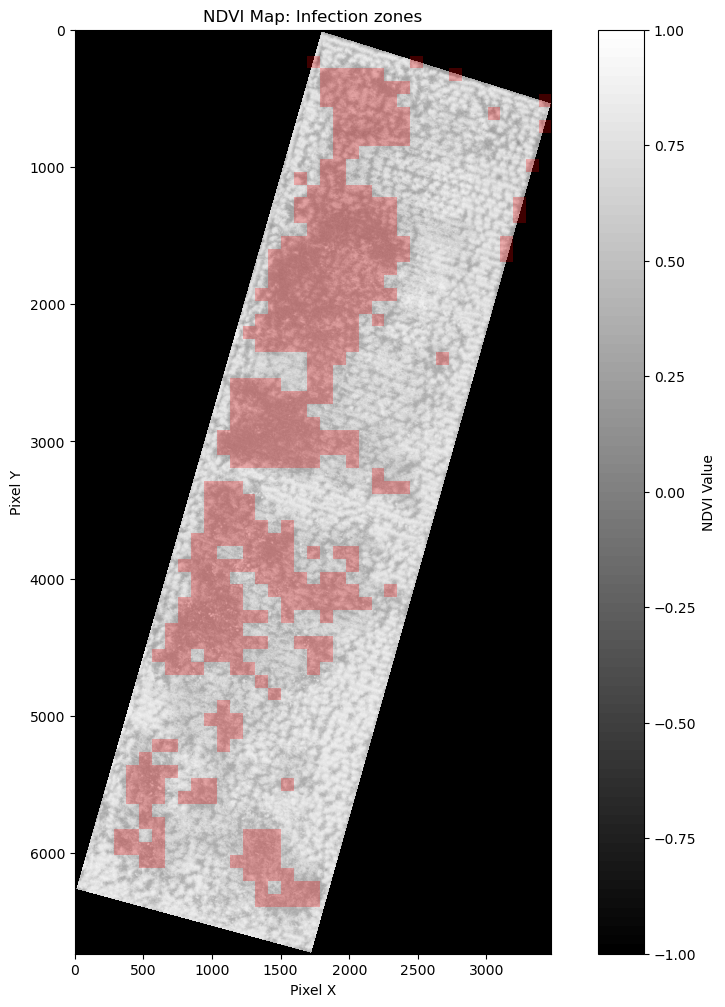

In [6]:
plt.figure(figsize=(12, 12))

img = plt.imshow(gu.ndvi, cmap=cmap, norm=norm)
plt.colorbar(img, label='NDVI Value')
plt.imshow(np.ma.masked_less(gu.ndvi, -1), cmap=cmap, norm=norm)

for chunk_y, chunk_x, infection_level in infected_chunks:
    start_y = chunk_y * gu.CHUNK_DIM_PX
    start_x = chunk_x * gu.CHUNK_DIM_PX
    
    height = min(gu.CHUNK_DIM_PX, gu.ndvi.shape[0] - start_y)
    width = min(gu.CHUNK_DIM_PX, gu.ndvi.shape[1] - start_x)
    
    alpha = 0.25
    
    rect = patches.Rectangle(
        (start_x, start_y),
        width,
        height,
        linewidth=0,
        edgecolor=None,
        facecolor=(1, 0, 0, alpha),
        zorder=3
    )
    
    plt.gca().add_patch(rect)

plt.title('NDVI Map: Infection zones')
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')

plt.show()